In [ ]:
#@title ENV

from google.colab import drive
drive.mount('/content/drive')


from google.colab import userdata
from google import genai
from google.genai import errors

try:
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

    if not GEMINI_API_KEY:
        raise ValueError("Colab 秘密金鑰中找不到 'GEMINI_API_KEY'，請檢查左側 🔑 裡面的名稱設定是否正確。")

    client = genai.Client(api_key=GEMINI_API_KEY)
    print("[OK] Gemini 用戶端初始化成功！")

except Exception as e:
    print(f"[錯誤] Gemini 初始化失敗。原因: {e}")


# =========================================================
# INSTALL
# =========================================================
!pip install mediapipe matplotlib fastdtw google-generativeai scikit-learn #opencv-python
!wget -O gesture_recognizer.task \
https://storage.googleapis.com/mediapipe-models/gesture_recognizer/gesture_recognizer/float16/1/gesture_recognizer.task
!pip install gradio

'''
# 1. 強制安裝不依賴圖形介面的 OpenCV Headless 版本
!pip uninstall -y opencv-python opencv-python-headless
!pip install opencv-python-headless

# 2. 安裝虛擬渲染快取（解決 MediaPipe 找不到螢幕的核心）
!apt-get install -y libgl1-mesa-glx
'''

Mounted at /content/drive
[錯誤] Gemini 初始化失敗。原因: Requesting secret GEMINI_API_KEY timed out. Secrets can only be fetched when running from the Colab UI.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 10.4 MB/s eta 0:00:00
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp312-cp312-linux_x86_64.whl size=567856 sha256=433c1dba0150f38eb08ca5e483fed9a91f509c0d55e79274b7d15d146d223cb9
  Stored in directory: /root/.cache/pip/wheels/ab/d0/26/b82cb0f49ae73e5e6bba4e8462fff2c9851d7bd2ec64f8891e
Successfully built fastdtw
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
--2026-08-15 14:27:23--  https://storage.googleapis.com/mediapipe-models/gesture_recognizer/gesture_recognizer/

### MUL

In [ ]:
# =========================================================
#@title FEATURE EXTRACTION
# =========================================================
import os
'''
# 強制讓系統在背景進行離線渲染（Headless 模式）
os.environ["XDG_RUNTIME_DIR"] = "/tmp/runtime-root"
os.environ["MEDIAPIPE_DISABLE_GPU"] = "1" # 如果堅持用 CPU，強制關閉 GPU 渲染通道
'''
import cv2
import time
import numpy as np
import mediapipe as mp
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

def get_angle(v1, v2):
    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)
    if norm1 == 0 or norm2 == 0: return 0.0
    dot = np.dot(v1 / norm1, v2 / norm2)
    dot = np.clip(dot, -1.0, 1.0)
    return np.arccos(dot)

def extract_single_hand(hand):
    wrist = np.array([hand[0].x, hand[0].y])
    center = np.array([hand[9].x, hand[9].y])
    palm_size = np.linalg.norm(center - wrist)
    if palm_size == 0: palm_size = 1.0

    feat = []
    for lm in hand:
        feat.append((lm.x - hand[0].x) / palm_size)
        feat.append((lm.y - hand[0].y) / palm_size)

    fingers = [[0,1,2,3,4], [0,5,6,7,8], [0,9,10,11,12], [0,13,14,15,16], [0,17,18,19,20]]
    for nodes in fingers:
        v1 = np.array([hand[nodes[2]].x - hand[nodes[1]].x, hand[nodes[2]].y - hand[nodes[1]].y])
        v2 = np.array([hand[nodes[3]].x - hand[nodes[2]].x, hand[nodes[3]].y - hand[nodes[2]].y])
        feat.append(get_angle(v1, v2))
    return np.array(feat, dtype=np.float32)

def extract_frame_features(result):

    LEFT = np.zeros(47, dtype=np.float32)
    RIGHT = np.zeros(47, dtype=np.float32)

    if not result.hand_landmarks:
        return np.concatenate([LEFT, RIGHT])

    if not result.handedness:
        return np.concatenate([LEFT, RIGHT])

    for i, hand in enumerate(result.hand_landmarks):

        if i >= len(result.handedness):
            continue

        label = result.handedness[i][0].category_name

        if label == "Left":
            LEFT = extract_single_hand(hand)

        elif label == "Right":
            RIGHT = extract_single_hand(hand)

    return np.concatenate([LEFT, RIGHT])

In [ ]:
#@title MEDIAPIPE / DATASET / DTW
class Timer:
    def __init__(self, block_name):
        self.block_name = block_name

    def __enter__(self):
        self.start_time = time.perf_counter()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.end_time = time.perf_counter()
        self.elapsed = self.end_time - self.start_time
        print(f"⏱  [{self.block_name}] 耗時: {self.elapsed:.4f} 秒")


# =========================================================
# 6. MEDIAPIPE INIT
# =========================================================
mp_tasks = mp.tasks
BaseOptions = mp_tasks.BaseOptions
GestureRecognizer = mp_tasks.vision.GestureRecognizer
GestureRecognizerOptions = mp_tasks.vision.GestureRecognizerOptions
VisionRunningMode = mp_tasks.vision.RunningMode

def create_recognizer():
    options = GestureRecognizerOptions(
        base_options=BaseOptions(
            model_asset_path="gesture_recognizer.task",
            delegate=mp.tasks.BaseOptions.Delegate.CPU # CPU/GPU 但colab會因為Headless找不到渲染噴錯
        ),
        running_mode=VisionRunningMode.VIDEO,
        num_hands=2,
        min_hand_detection_confidence=0.7,
        min_hand_presence_confidence=0.7,
        min_tracking_confidence=0.7
    )
    return GestureRecognizer.create_from_options(options)


# =========================================================
# 7. LOAD DATASET & CLUSTER
# =========================================================
def load_dataset(dataset_root):

    db = []

    if not os.path.exists(dataset_root):
        print(f"找不到資料集: {dataset_root}")
        return []

    for folder in os.listdir(dataset_root):

        folder_path = os.path.join(dataset_root, folder)

        if not os.path.isdir(folder_path):
            continue

        for f in os.listdir(folder_path):

            if not f.endswith(".npy"):
                continue

            seq = np.load(
                os.path.join(folder_path, f)
            )

            label = os.path.splitext(f)[0]

            db.append(
                (label, seq)
            )

    print(f"[INFO] 載入 {len(db)} 個症狀樣本")

    return db

# =========================================================
# 8. MATCHER

# 找出 DTW 最佳匹配
# 與 predict_symptom() 相同邏輯，
# 但額外把 best sequence 保留下來，
# 給 visualization 使用。
# =========================================================

def predict_symptom_with_sequence(
    query_seq,
    db,
    THRESHOLD=2.0
):

    best_label = "unknown"
    best_dist = float("inf")
    best_seq = None

    print("\n===== DTW Matching =====")

    for label, seq in db:

        if len(seq) == 0:
            continue

        dist, _ = fastdtw(
            query_seq,
            seq,
            dist=euclidean
        )

        dist /= len(query_seq)

        print(f"{label:15s} {dist:.4f}")

        if dist < best_dist:

            best_dist = dist
            best_label = label
            best_seq = seq

    print(
        f"\nBEST = {best_label} "
        f"({best_dist:.4f})"
    )

    if best_dist > THRESHOLD:

        return "unknown", best_dist, best_seq

    return best_label, best_dist, best_seq


# =========================================================
# 9. VIDEO -> FEATURE SEQUENCE (細分計時 MediaPipe 與 OpenCV)
# =========================================================
def video_to_sequence(video_path):
    with Timer("MediaPipe 階段 - 1. 模型初始化"):
        recognizer = create_recognizer()

    sequence = []

    with Timer("MediaPipe 階段 - 2. 影片開啟 (OpenCV)"):
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        if fps == 0: fps = 30
        frame_ms = 1000 / fps
        timestamp = 0
        frame_idx = 0

    total_opencv_time = 0.0
    total_mediapipe_time = 0.0
    total_extract_time = 0.0

    while cap.isOpened():
        # 統計 OpenCV 讀影格時間
        t0 = time.perf_counter()
        ret, frame = cap.read()
        if not ret: break
        t1 = time.perf_counter()
        total_opencv_time += (t1 - t0)

        # 統計 MediaPipe 推理時間
        t2 = time.perf_counter()
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = recognizer.recognize_for_video(mp_image, int(timestamp))
        t3 = time.perf_counter()
        total_mediapipe_time += (t3 - t2)

        # 統計數學特徵提取與角度計算時間
        t4 = time.perf_counter()
        feat = extract_frame_features(result)
        sequence.append(feat)
        t5 = time.perf_counter()
        total_extract_time += (t5 - t4)

        frame_idx += 1
        timestamp += frame_ms

    cap.release()
    recognizer.close()

    print(f"⏱  [MediaPipe 階段 - 3. 影片迴圈處理] 總影格數: {frame_idx} 幀")
    print(f"   ├── OpenCV 讀取影格總計   : {total_opencv_time:.4f} 秒")
    print(f"   ├── MediaPipe 模型預測總計 : {total_mediapipe_time:.4f} 秒 (重點觀察對象)")
    print(f"   └── 特徵/角度純數學計算總計 : {total_extract_time:.4f} 秒")

    return np.array(sequence, dtype=np.float32)




In [ ]:
# =========================================================
#@title GEMINI REWRITE

# 模擬後續接收手語資料後的其他API應用
# =========================================================
SYMPTOM_GUIDE = {

    "cold": "請前往二樓家庭醫學科",
    "fever": "請前往二樓家庭醫學科",
    "cough": "請前往二樓胸腔內科",
    "headache": "請前往三樓神經內科",
    "stomachache": "請前往一樓腸胃科",
    "dizziness": "請前往三樓神經內科",
    "insomnia": "請前往身心科門診",
    "runny_nose": "請前往二樓耳鼻喉科",
    "fall": "請前往急診或骨科",

    "unknown": "請洽服務台"
}

def medical_response(symptom):

    guide = SYMPTOM_GUIDE.get(
        symptom,
        "請洽服務台"
    )

    prompt = f"""
          症狀:{symptom}

          對應導診資訊:
          {guide}

          請整理成：

          症狀確認：
          建議科別：
          診間位置：

          50字內
          """

    try:

        response = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=prompt
        )

        return response.text.strip()

    except Exception:

        return guide


In [ ]:
# =========================================================
#@title VISUALIZATION — DTW Skeleton + Alignment
# =========================================================

import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean


# ---------------------------------------------------------
# 1. 從 94D feature 重建單手 landmark
#
# 每隻手：
#   42D = 21 landmarks × (x,y)
#    5D = finger angles
#
# 注意：
#   這裡只能重建「正規化後」的手部骨架
#   無法恢復原影片中的絕對位置
# ---------------------------------------------------------

HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),       # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),       # Index
    (0, 9), (9, 10), (10, 11), (11, 12),  # Middle
    (0, 13), (13, 14), (14, 15), (15, 16),# Ring
    (0, 17), (17, 18), (18, 19), (19, 20) # Pinky
]


def reconstruct_hand(feature_47):
    """
    將 47D hand feature 還原成：
        (21, 2) normalized landmark coordinates

    feature:
        [0:42] = 21 × (x,y)
        [42:47] = finger angles
    """

    if feature_47 is None or len(feature_47) < 42:
        return np.zeros((21, 2), dtype=np.float32)

    landmarks = feature_47[:42].reshape(21, 2)

    return landmarks


# ---------------------------------------------------------
# 2. 畫單手骨架
# ---------------------------------------------------------

def draw_hand(ax, feature_47, title="", flip_x=False):

    points = reconstruct_hand(feature_47)

    # 如果需要鏡像，可以在這裡處理
    if flip_x:
        points = points.copy()
        points[:, 0] *= -1

    # 判斷是不是 zero vector
    is_missing = np.allclose(points, 0)

    if is_missing:
        ax.text(
            0.5, 0.5,
            "NO HAND DETECTED",
            ha="center",
            va="center",
            fontsize=12
        )
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_aspect("equal")
        ax.set_title(title)
        ax.axis("off")
        return

    # 畫骨架
    for a, b in HAND_CONNECTIONS:

        ax.plot(
            [points[a, 0], points[b, 0]],
            [points[a, 1], points[b, 1]],
            linewidth=2
        )

    # 畫 landmark
    ax.scatter(
        points[:, 0],
        points[:, 1],
        s=20
    )

    # Wrist 編號
    ax.text(
        points[0, 0],
        points[0, 1],
        "  wrist",
        fontsize=8
    )

    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(2.0, -2.0)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)
    ax.set_title(title)


# ---------------------------------------------------------
# 3. 畫左右手
# ---------------------------------------------------------

def draw_frame_skeleton(
    ax,
    feature_94,
    title="",
    show_right=True,
    show_left=True
):

    left = feature_94[:47]
    right = feature_94[47:94]

    left_points = reconstruct_hand(left)
    right_points = reconstruct_hand(right)

    left_missing = np.allclose(left_points, 0)
    right_missing = np.allclose(right_points, 0)

    # 左手
    if show_left and not left_missing:

        for a, b in HAND_CONNECTIONS:

            ax.plot(
                [left_points[a, 0], left_points[b, 0]],
                [left_points[a, 1], left_points[b, 1]],
                linewidth=2
            )

        ax.scatter(
            left_points[:, 0],
            left_points[:, 1],
            s=20
        )

    # 右手
    if show_right and not right_missing:

        for a, b in HAND_CONNECTIONS:

            ax.plot(
                [right_points[a, 0], right_points[b, 0]],
                [right_points[a, 1], right_points[b, 1]],
                linewidth=2
            )

        ax.scatter(
            right_points[:, 0],
            right_points[:, 1],
            s=20
        )

    # 狀態文字
    status = []

    if left_missing:
        status.append("Left: missing")
    else:
        status.append("Left: detected")

    if right_missing:
        status.append("Right: missing")
    else:
        status.append("Right: detected")

    ax.text(
        0.02,
        0.02,
        "\n".join(status),
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment="bottom"
    )

    ax.set_xlim(-2.0, 2.0)
    ax.set_ylim(2.0, -2.0)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)
    ax.set_title(title)


# ---------------------------------------------------------
# 4. 建立 DTW path
#
# 注意：
# fastdtw 本身已經回傳 path
# path 中：
#   (query_frame, db_frame)
# ---------------------------------------------------------

def get_dtw_path(query_seq, db_seq):

    dist, path = fastdtw(
        query_seq,
        db_seq,
        dist=euclidean
    )

    return dist, path


# ---------------------------------------------------------
# 5. 找「每 0.5 秒」對應到 DB 的 frame
# ---------------------------------------------------------

def get_sampled_alignment(
    query_seq,
    db_seq,
    query_fps=30,
    db_fps=30,
    interval=0.5
):

    dist, path = get_dtw_path(
        query_seq,
        db_seq
    )

    path = np.array(path)

    query_indices = path[:, 0]
    db_indices = path[:, 1]

    max_query_frame = len(query_seq) - 1

    sample_frames = np.arange(
        0,
        max_query_frame + 1,
        max(1, int(query_fps * interval))
    )

    results = []

    for q_frame in sample_frames:

        # 找 path 中最接近 query frame 的位置
        idx = np.argmin(
            np.abs(query_indices - q_frame)
        )

        q_idx = query_indices[idx]
        db_idx = db_indices[idx]

        results.append({
            "query_frame": int(q_idx),
            "db_frame": int(db_idx),
            "query_time": q_idx / query_fps,
            "db_time": db_idx / db_fps
        })

    return dist, path, results


# ---------------------------------------------------------
# 6. 顯示每 0.5 秒的左右對照
# ---------------------------------------------------------

def visualize_dtw_skeleton(
    query_seq,
    db_seq,
    query_label="USER",
    db_label="DATABASE",
    query_fps=30,
    db_fps=30,
    interval=0.5
):

    dist, path, samples = get_sampled_alignment(
        query_seq,
        db_seq,
        query_fps=query_fps,
        db_fps=db_fps,
        interval=interval
    )

    print("=" * 70)
    print("DTW SKELETON ALIGNMENT")
    print("=" * 70)

    print(f"Query : {query_label}")
    print(f"DB    : {db_label}")
    print(f"DTW raw distance : {dist:.4f}")
    print(f"Normalized       : {dist / len(query_seq):.4f}")

    print("\nTime Alignment")
    print("-" * 70)

    for item in samples:

        print(
            f"USER {item['query_time']:5.2f}s "
            f"(frame {item['query_frame']:4d})"
            f"  --->  "
            f"DB {item['db_time']:5.2f}s "
            f"(frame {item['db_frame']:4d})"
        )

    print("=" * 70)

    # -----------------------------------------------------
    # 每 0.5 秒畫一次
    # -----------------------------------------------------

    for item in samples:

        q_idx = item["query_frame"]
        db_idx = item["db_frame"]

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(10, 5)
        )

        draw_frame_skeleton(
            axes[0],
            query_seq[q_idx],
            title=(
                f"USER\n"
                f"{query_label}\n"
                f"t = {item['query_time']:.2f}s\n"
                f"frame = {q_idx}"
            )
        )

        draw_frame_skeleton(
            axes[1],
            db_seq[db_idx],
            title=(
                f"DATABASE\n"
                f"{db_label}\n"
                f"t = {item['db_time']:.2f}s\n"
                f"frame = {db_idx}"
            )
        )

        plt.suptitle(
            "DTW Frame Alignment",
            fontsize=14
        )

        plt.tight_layout()
        plt.show()


    # -----------------------------------------------------
    # DTW Alignment Map
    # -----------------------------------------------------

    path = np.array(path)

    plt.figure(figsize=(9, 7))

    plt.plot(
        path[:, 0],
        path[:, 1],
        linewidth=1.5
    )

    plt.scatter(
        path[:, 0],
        path[:, 1],
        s=5
    )

    plt.xlabel(
        f"User Frame ({len(query_seq)} frames)"
    )

    plt.ylabel(
        f"Database Frame ({len(db_seq)} frames)"
    )

    plt.title(
        "DTW Alignment Path"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    # 畫 ideal diagonal
    plt.plot(
        [0, len(query_seq) - 1],
        [0, len(db_seq) - 1],
        linestyle="--",
        alpha=0.5
    )

    plt.tight_layout()
    plt.show()

    return {
        "distance": dist,
        "path": path,
        "samples": samples
    }


# =========================================================
# 7. 找 DB 中最接近的樣本並直接視覺化
# =========================================================

def visualize_prediction(
    query_seq,
    db,
    query_fps=30,
    interval=0.5
):

    best_label = "unknown"
    best_seq = None
    best_dist = float("inf")

    for label, seq in db:

        if len(seq) == 0:
            continue

        dist, _ = fastdtw(
            query_seq,
            seq,
            dist=euclidean
        )

        normalized_dist = dist / len(query_seq)

        if normalized_dist < best_dist:

            best_dist = normalized_dist
            best_label = label
            best_seq = seq

    if best_seq is None:

        print("找不到有效的 DB sample")
        return None

    print("\n")
    print("=" * 70)
    print("BEST MATCH")
    print("=" * 70)
    print(f"Label    : {best_label}")
    print(f"Distance : {best_dist:.4f}")
    print(f"Query shape : {query_seq.shape}")
    print(f"DB shape    : {best_seq.shape}")
    print("=" * 70)

    return visualize_dtw_skeleton(
        query_seq,
        best_seq,
        query_label="USER QUERY",
        db_label=best_label,
        query_fps=query_fps,
        db_fps=query_fps,
        interval=interval
    )

### RUN

In [ ]:
# =========================================================
#@title UI
# =========================================================

DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/dataset_15/dataset_features" # @param {"type":"string"}

print("[INFO] loading dataset...")
db = load_dataset(DATASET_PATH)
print(f"[OK] db size = {len(db)}")


# =========================================================
# DTW VISUALIZATION CONTROL
# =========================================================

ENABLE_DTW_VISUALIZATION = True

# 最近一次辨識的 visualization 資料
LAST_QUERY_SEQ = None
LAST_DB_SEQ = None
LAST_DB_LABEL = None
LAST_DT_DISTANCE = None


# =========================================================
# DTW MATCHING
#
# 和原本 predict_symptom() 幾乎一樣，
# 但額外保留「最佳匹配的 sequence」
# 給 visualization 使用。
# =========================================================

def predict_symptom_with_sequence(
    query_seq,
    db,
    THRESHOLD=2.0
):

    best_label = "unknown"
    best_dist = float("inf")
    best_seq = None

    print("\n===== DTW Matching =====")

    for label, seq in db:

        if len(seq) == 0:
            continue

        dist, _ = fastdtw(
            query_seq,
            seq,
            dist=euclidean
        )

        # 與原本 predict_symptom() 相同
        normalized_dist = dist / len(query_seq)

        print(
            f"{label:15s} {normalized_dist:.4f}"
        )

        if normalized_dist < best_dist:

            best_dist = normalized_dist
            best_label = label
            best_seq = seq

    print(
        f"\nBEST = {best_label} "
        f"({best_dist:.4f})"
    )

    if best_dist > THRESHOLD:

        return "unknown", best_dist, best_seq

    return best_label, best_dist, best_seq


# =========================================================
# Gradio
# =========================================================

import gradio as gr


# =========================================================
# MAIN SYSTEM
# =========================================================

def run_system(video_file):

    global LAST_QUERY_SEQ
    global LAST_DB_SEQ
    global LAST_DB_LABEL
    global LAST_DT_DISTANCE

    if video_file is None:
        return "請上傳影片", "無結果"

    # -----------------------------------------------------
    # Gradio Video input
    # -----------------------------------------------------

    if isinstance(video_file, dict):
        video_path = video_file["path"]
    else:
        video_path = video_file

    # -----------------------------------------------------
    # 1. Video → Feature Sequence
    # -----------------------------------------------------

    seq = video_to_sequence(video_path)

    if len(seq) == 0:

        return "辨識失敗", "請重新錄製"

    print(
        f"\n[INFO] Query sequence shape = {seq.shape}"
    )

    # -----------------------------------------------------
    # 2. DTW Matching
    # -----------------------------------------------------

    symptom, dist, best_seq = predict_symptom_with_sequence(
        seq,
        db
    )

    # -----------------------------------------------------
    # 3. 保存 visualization 所需資料
    #
    # 注意：
    # 這裡「只保存資料」
    # 不在 Gradio callback 裡 plt.show()
    # -----------------------------------------------------

    if ENABLE_DTW_VISUALIZATION:

        LAST_QUERY_SEQ = seq
        LAST_DB_SEQ = best_seq
        LAST_DB_LABEL = symptom
        LAST_DT_DISTANCE = dist

        print("\n")
        print("=" * 70)
        print("DTW Visualization data ready.")
        print("請在 Colab 另一個 cell 執行：")
        print()
        print("    show_last_dtw()")
        print()
        print("=" * 70)

    # -----------------------------------------------------
    # 4. Gemini Medical Response
    # -----------------------------------------------------

    reply = medical_response(symptom)

    return symptom, reply


# =========================================================
# SHOW LAST DTW VISUALIZATION
#
# Gradio 跑完後：
#
#     show_last_dtw()
#
# 就會在 Colab notebook 顯示 matplotlib。
# =========================================================

def show_last_dtw(
    interval=0.2,
    query_fps=30,
    db_fps=30
):

    # -----------------------------------------------------
    # Check
    # -----------------------------------------------------

    if LAST_QUERY_SEQ is None:

        print("=" * 70)
        print("目前沒有 visualization 資料。")
        print("請先從 Gradio 上傳影片並執行一次辨識。")
        print("=" * 70)

        return

    if LAST_DB_SEQ is None:

        print("=" * 70)
        print("目前沒有找到最佳 DB sequence。")
        print("=" * 70)

        return

    # -----------------------------------------------------
    # Information
    # -----------------------------------------------------

    print("=" * 70)
    print("顯示最近一次 DTW Visualization")
    print("=" * 70)

    print(
        f"USER shape : {LAST_QUERY_SEQ.shape}"
    )

    print(
        f"DB shape   : {LAST_DB_SEQ.shape}"
    )

    print(
        f"DB label   : {LAST_DB_LABEL}"
    )

    if LAST_DT_DISTANCE is not None:

        print(
            f"Normalized DTW distance : "
            f"{LAST_DT_DISTANCE:.4f}"
        )

    print(
        f"Sampling interval       : "
        f"{interval:.2f} sec"
    )

    print("=" * 70)

    # -----------------------------------------------------
    # Visualization
    # -----------------------------------------------------

    result = visualize_dtw_skeleton(
        query_seq=LAST_QUERY_SEQ,
        db_seq=LAST_DB_SEQ,
        query_label="USER QUERY",
        db_label=LAST_DB_LABEL,
        query_fps=query_fps,
        db_fps=db_fps,
        interval=interval
    )

    return result


# =========================================================
# Gradio Interface
# =========================================================

with gr.Blocks(
    title="醫療手語導診系統",
    theme=gr.themes.Soft()
) as demo:

    # ================= HEADER =================

    gr.Markdown("""
    # 🏥 醫療手語導診系統
    ### MediaPipe + DTW + Gemini AI
    ---
    """)

    # ================= INPUT AREA =================

    with gr.Row():

        with gr.Column(scale=1):

            video_input = gr.Video(
                label="📹 請上傳手語影片",
                format="mp4"
            )

            run_btn = gr.Button(
                "🧠 開始辨識",
                variant="primary"
            )

            gr.Markdown("""
            ### 📌 使用流程

            1. 上傳手語影片
            2. 點擊辨識
            3. 查看症狀 + 導診結果
            4. 若需要 Debug：
               在 Colab 執行 `show_last_dtw()`
            """)

    # ================= OUTPUT AREA =================

    with gr.Row():

        with gr.Column():

            symptom_box = gr.Textbox(
                label="🧾 辨識症狀",
                interactive=False
            )

        with gr.Column():

            result_box = gr.Textbox(
                label="🏥 導診建議",
                interactive=False,
                lines=4
            )

    # ================= ADVANCED INFO =================

    with gr.Accordion(
        "📊 Debug / 技術資訊",
        open=False
    ):

        gr.Markdown("""
        DTW distance 與 alignment visualization
        不會嵌入此 UI。

        請於 Colab Notebook 執行：

        `show_last_dtw()`
        """)

    # ================= ACTION =================

    run_btn.click(
        fn=run_system,
        inputs=video_input,
        outputs=[
            symptom_box,
            result_box
        ]
    )


# =========================================================
# LAUNCH
# =========================================================

demo.launch(
    share=True,
    debug=True,
    inline=False
)

[INFO] loading dataset...
[INFO] 載入 15 個症狀樣本
[OK] db size = 15


/tmp/ipykernel_1612/3999653883.py:259: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6f8dab22927dc27bda.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
⏱  [MediaPipe 階段 - 1. 模型初始化] 耗時: 0.0479 秒
⏱  [MediaPipe 階段 - 2. 影片開啟 (OpenCV)] 耗時: 0.0054 秒
⏱  [MediaPipe 階段 - 3. 影片迴圈處理] 總影格數: 130 幀
   ├── OpenCV 讀取影格總計   : 0.1577 秒
   ├── MediaPipe 模型預測總計 : 5.9647 秒 (重點觀察對象)
   └── 特徵/角度純數學計算總計 : 0.0247 秒

[INFO] Query sequence shape = (130, 94)

===== DTW Matching =====
hypertension    4.1236
runny_nose      1.7082
fall            5.4941
vomit           2.6801
swelling        3.6100
fracture        4.5507
diarrhea        5.1306
fever           3.4025
injuried        3.9858
insomnia        6.1055
cold       

顯示最近一次 DTW Visualization
USER shape : (130, 94)
DB shape   : (163, 94)
DB label   : runny_nose
Normalized DTW distance : 1.7082
Sampling interval       : 0.20 sec
DTW SKELETON ALIGNMENT
Query : USER QUERY
DB    : runny_nose
DTW raw distance : 222.0619
Normalized       : 1.7082

Time Alignment
----------------------------------------------------------------------
USER  0.00s (frame    0)  --->  DB  0.00s (frame    0)
USER  0.20s (frame    6)  --->  DB  1.43s (frame   43)
USER  0.40s (frame   12)  --->  DB  1.63s (frame   49)
USER  0.60s (frame   18)  --->  DB  1.83s (frame   55)
USER  0.80s (frame   24)  --->  DB  2.07s (frame   62)
USER  1.00s (frame   30)  --->  DB  2.27s (frame   68)
USER  1.20s (frame   36)  --->  DB  2.47s (frame   74)
USER  1.40s (frame   42)  --->  DB  2.67s (frame   80)
USER  1.60s (frame   48)  --->  DB  2.87s (frame   86)
USER  1.80s (frame   54)  --->  DB  3.07s (frame   92)
USER  2.00s (frame   60)  --->  DB  3.53s (frame  106)
USER  2.20s (frame   66)  --->

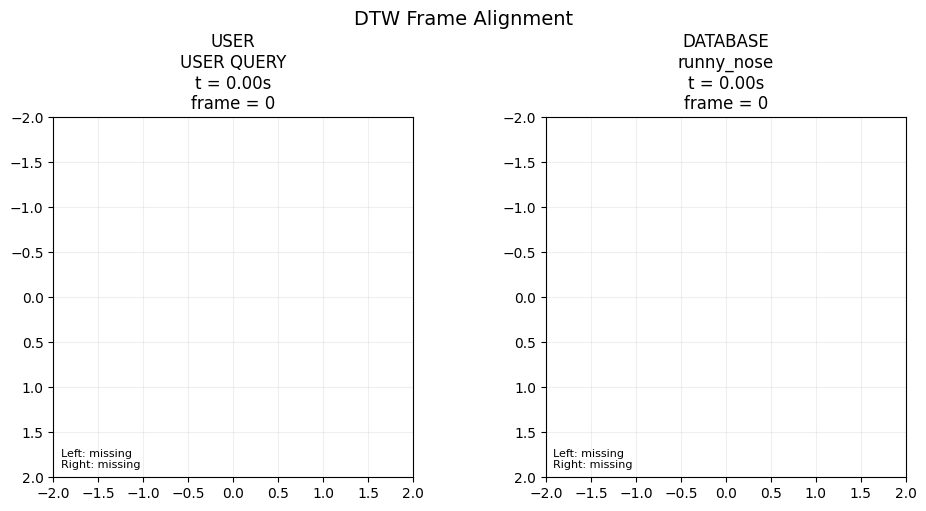

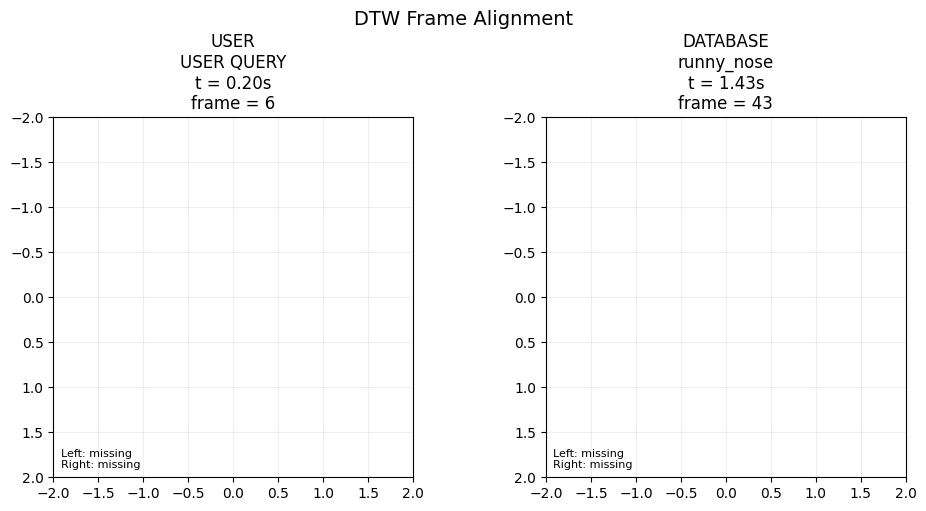

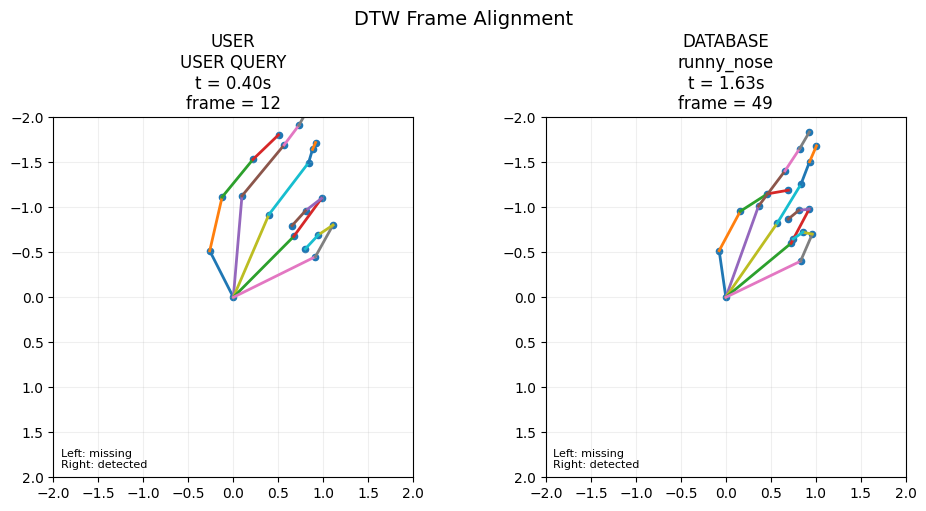

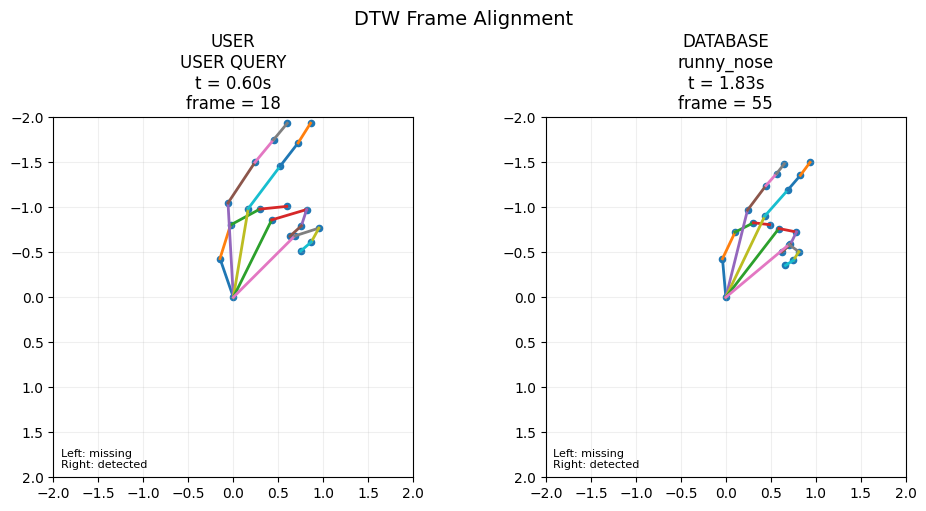

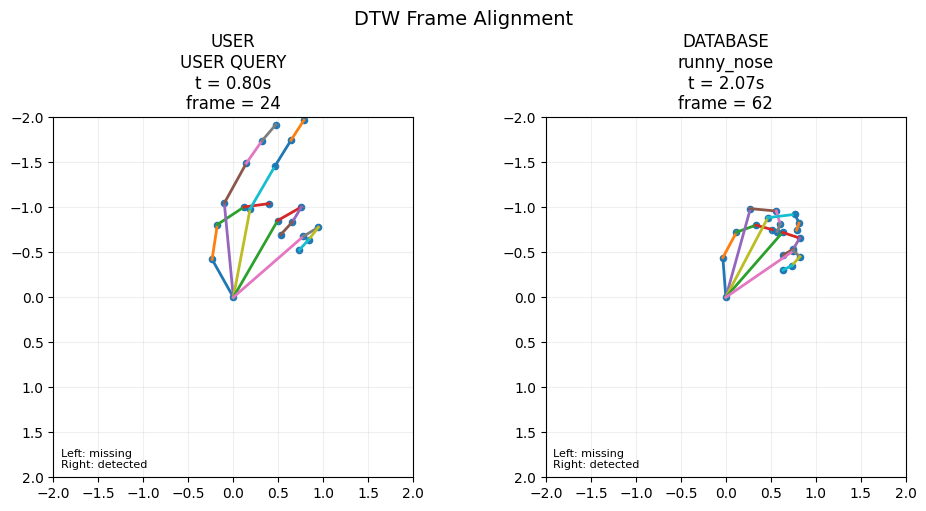

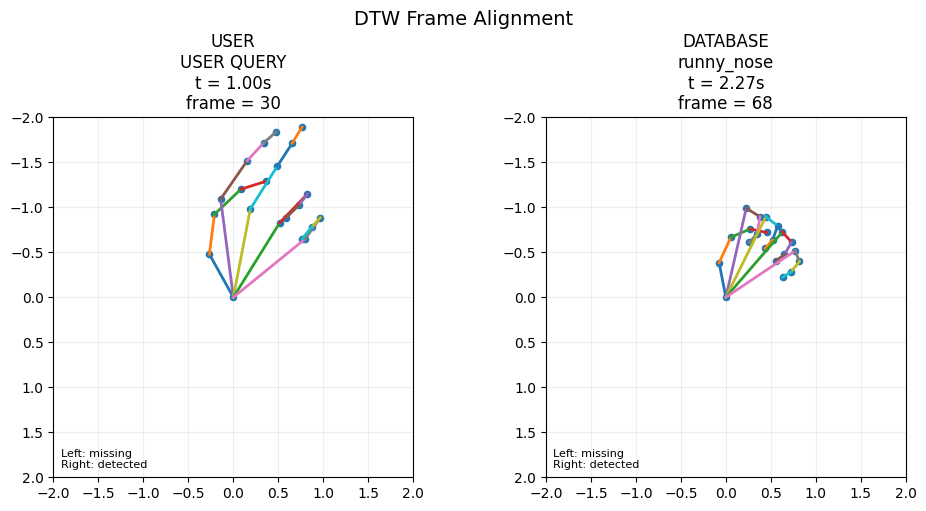

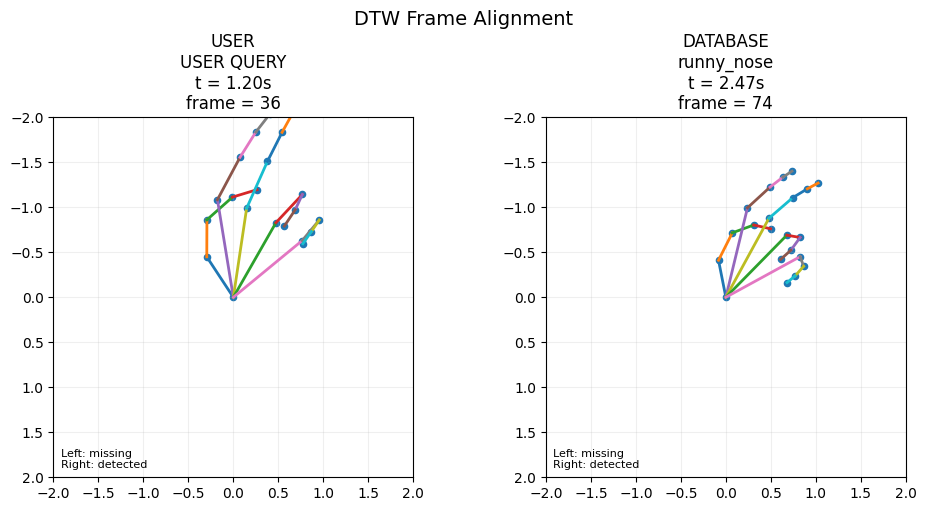

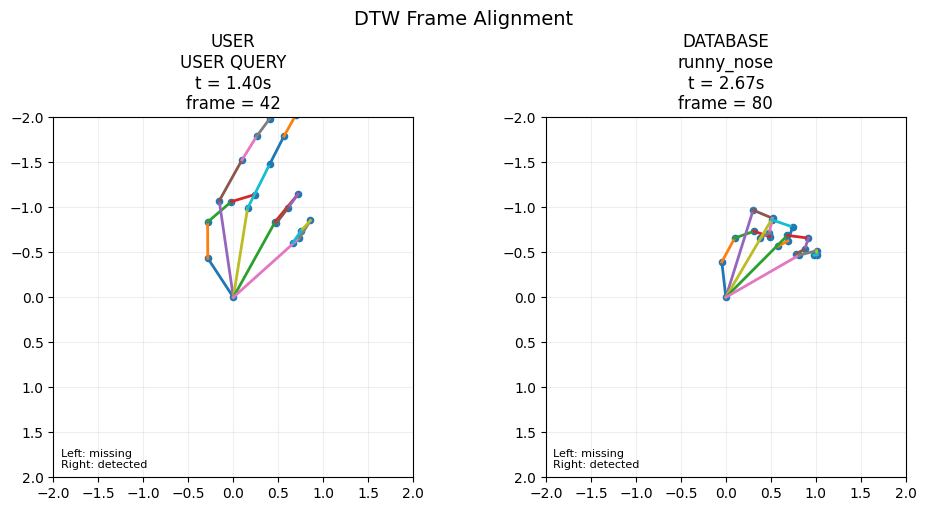

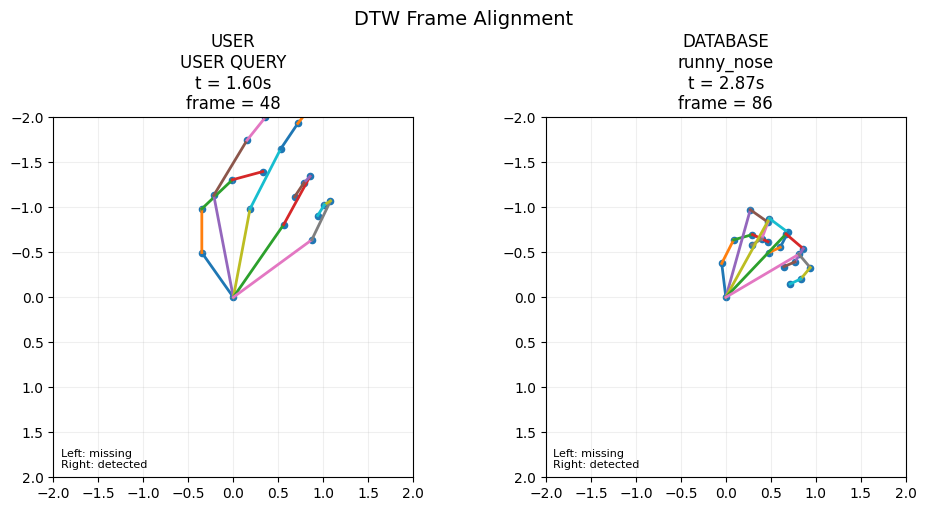

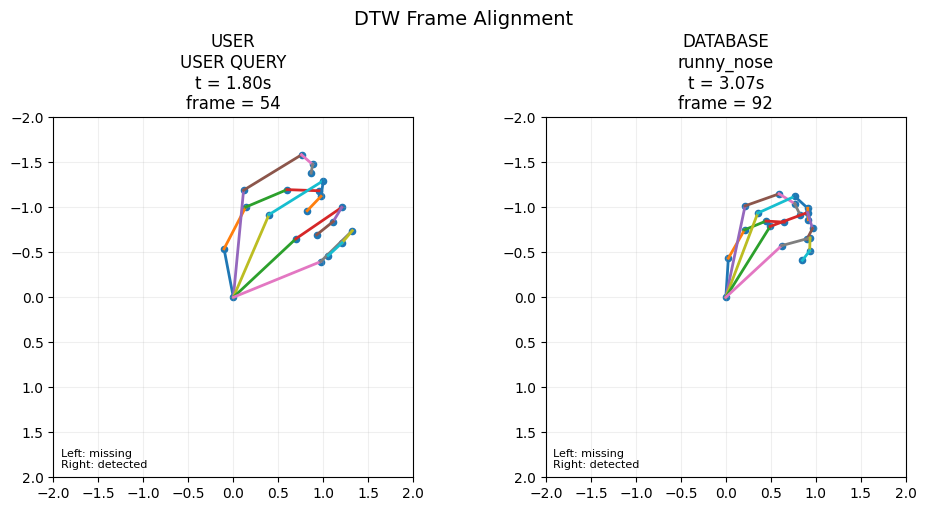

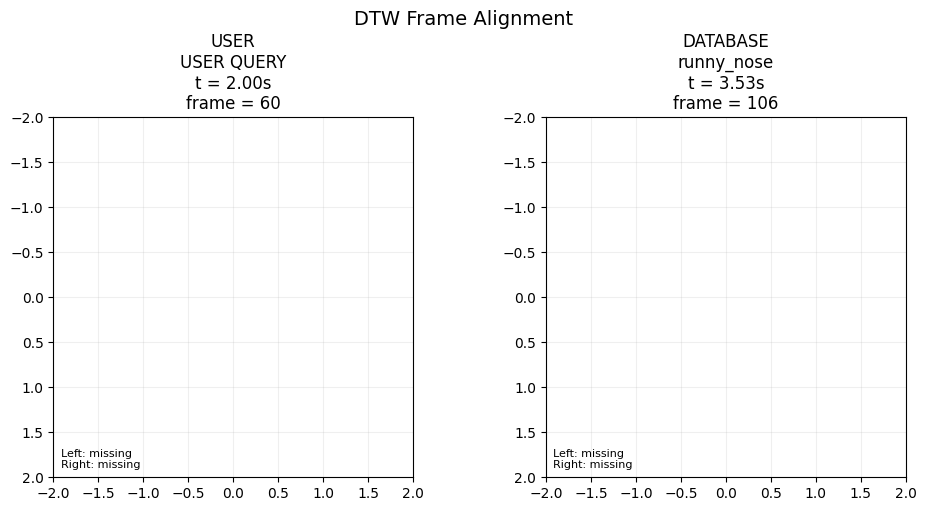

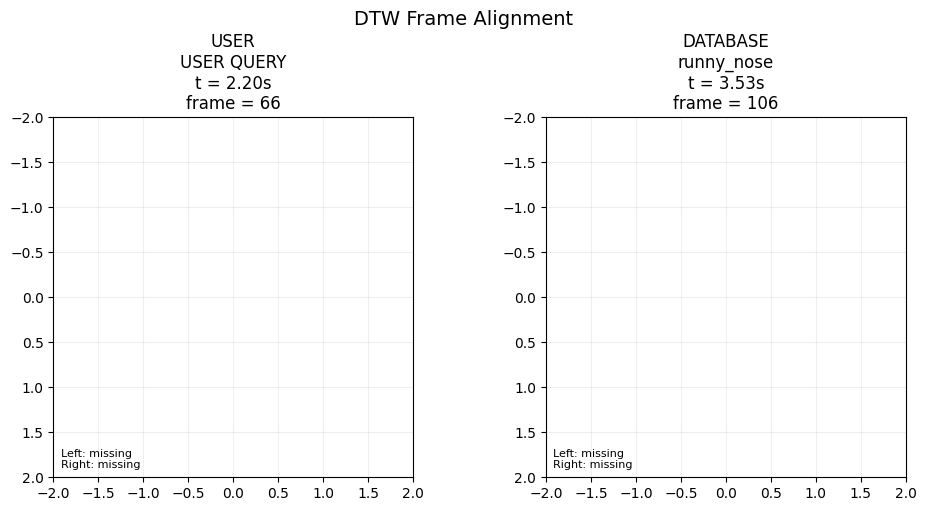

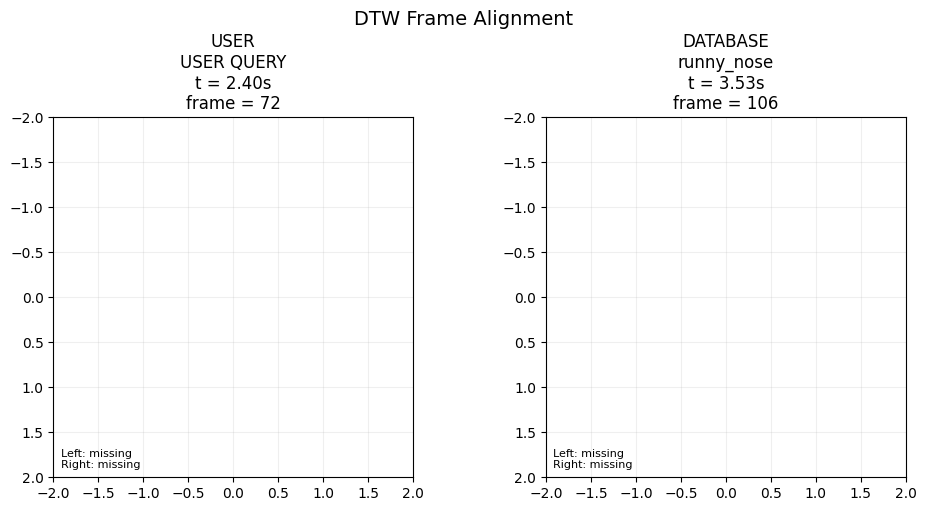

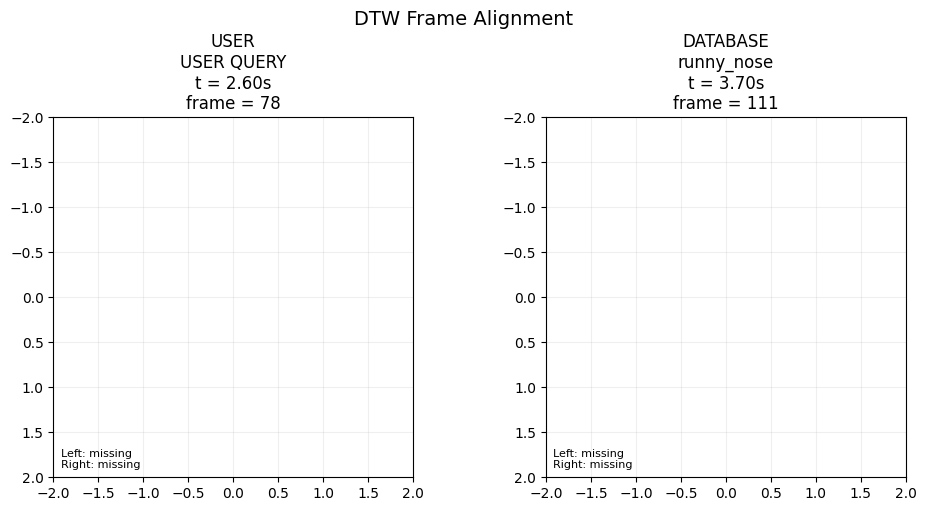

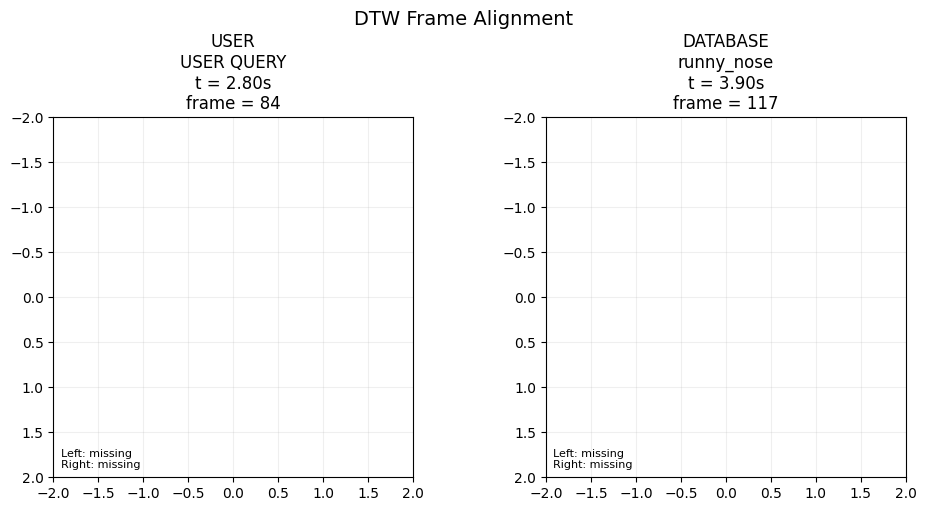

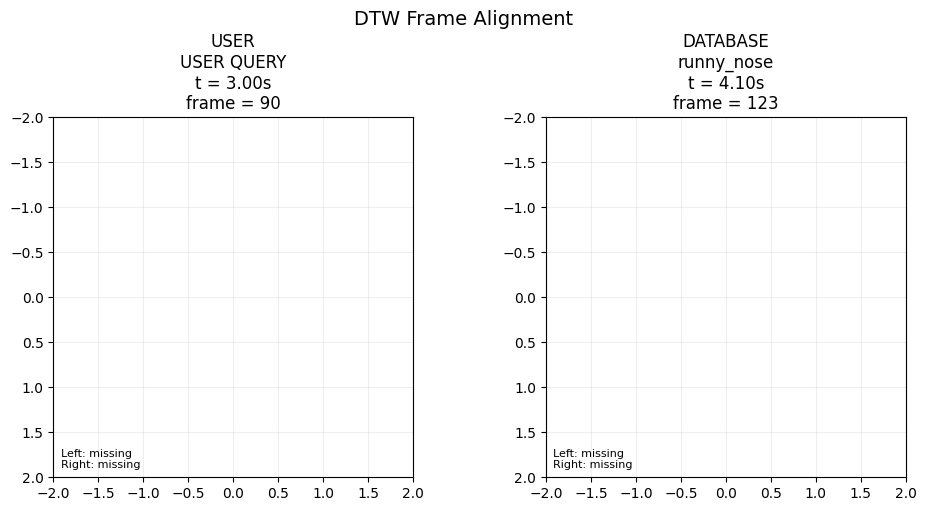

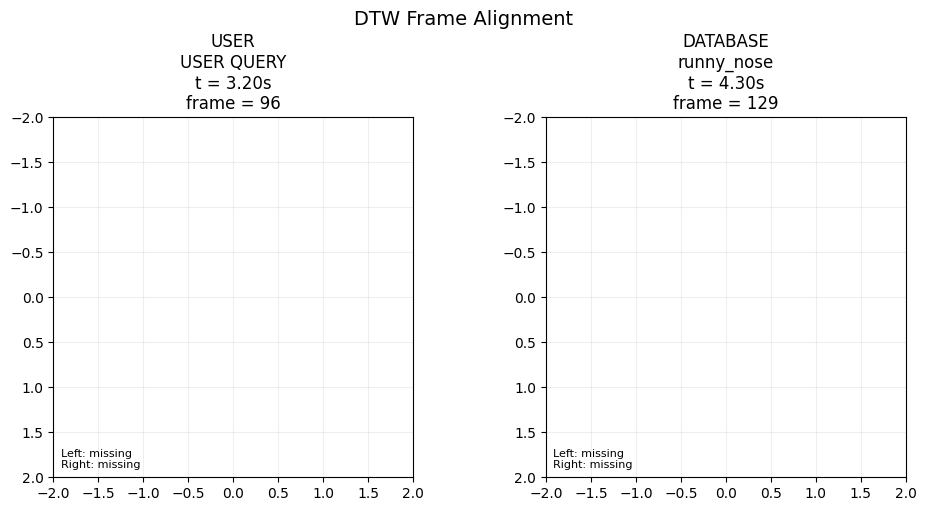

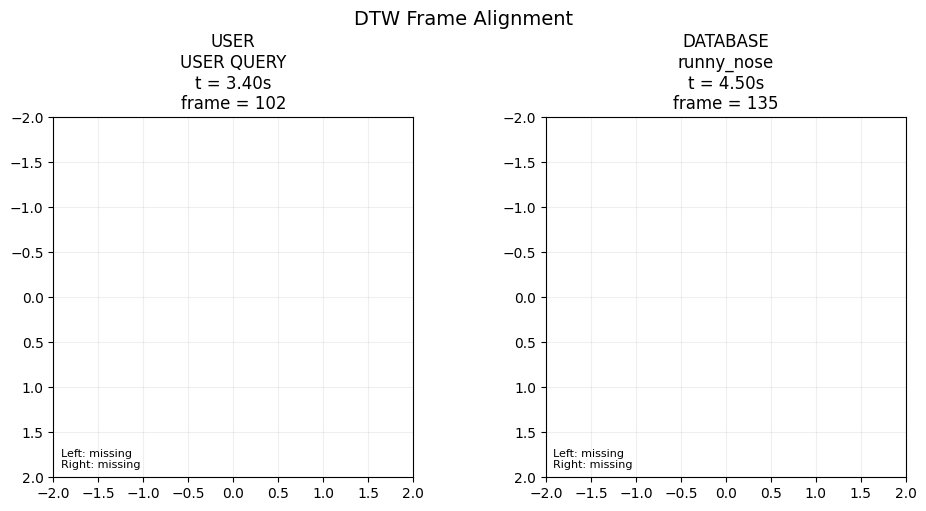

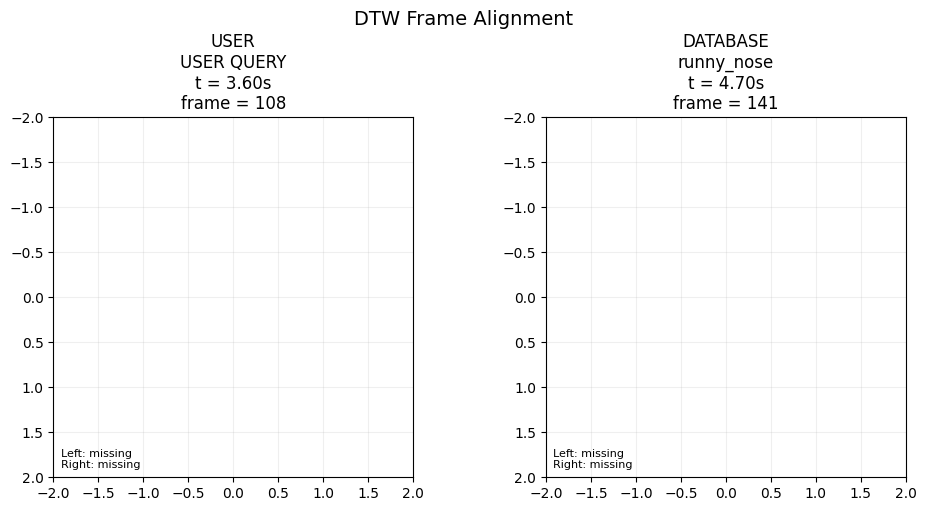

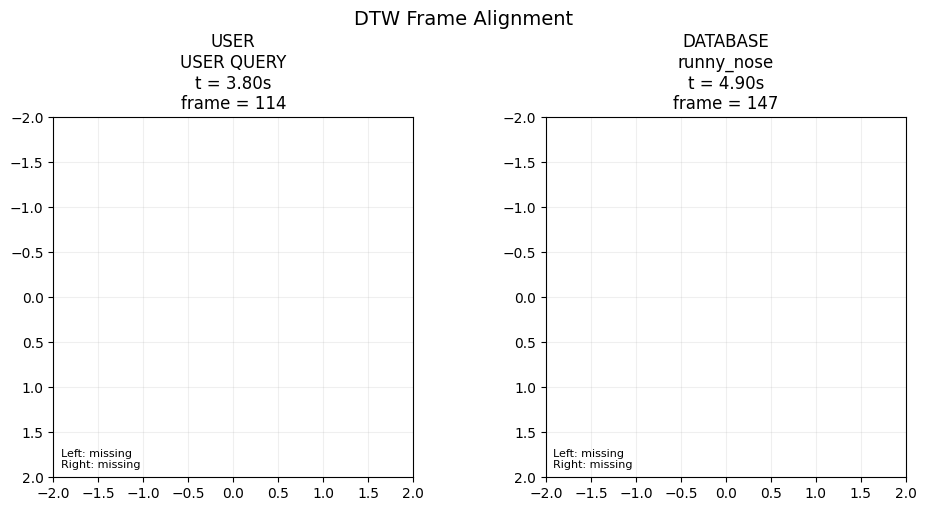

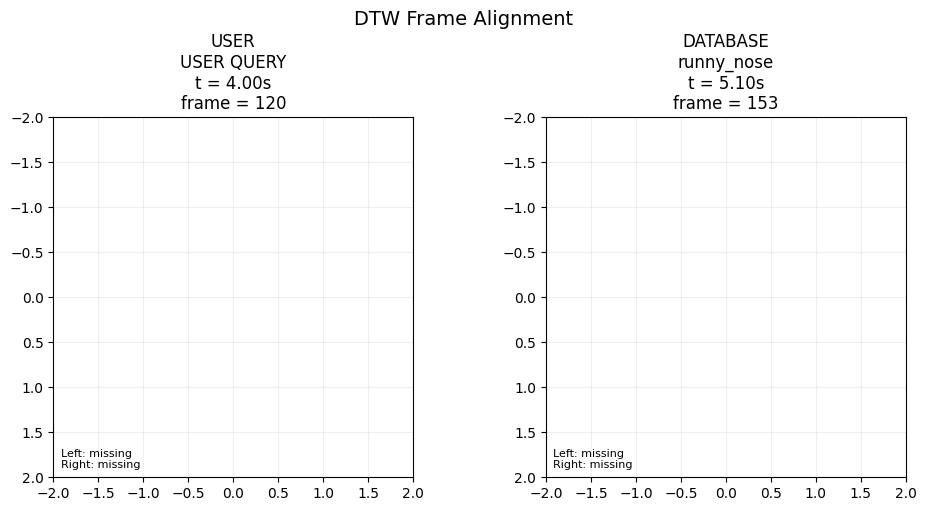

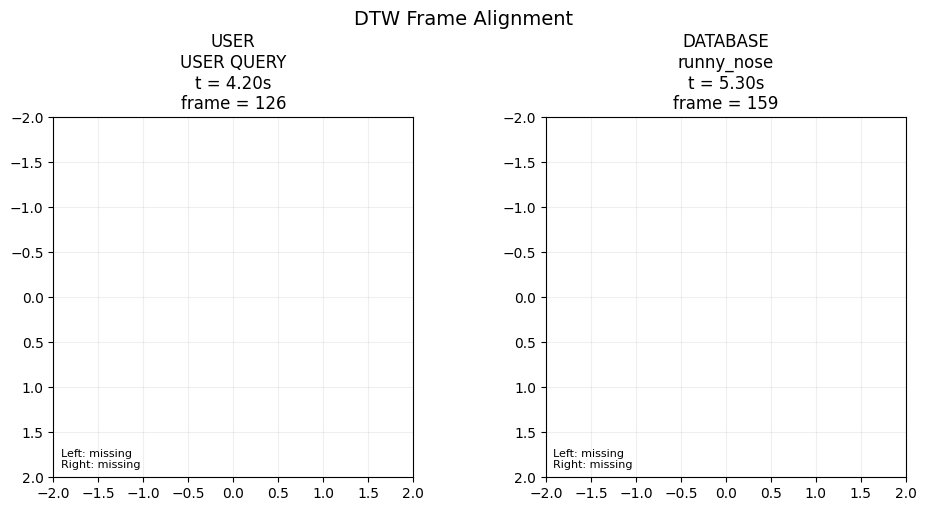

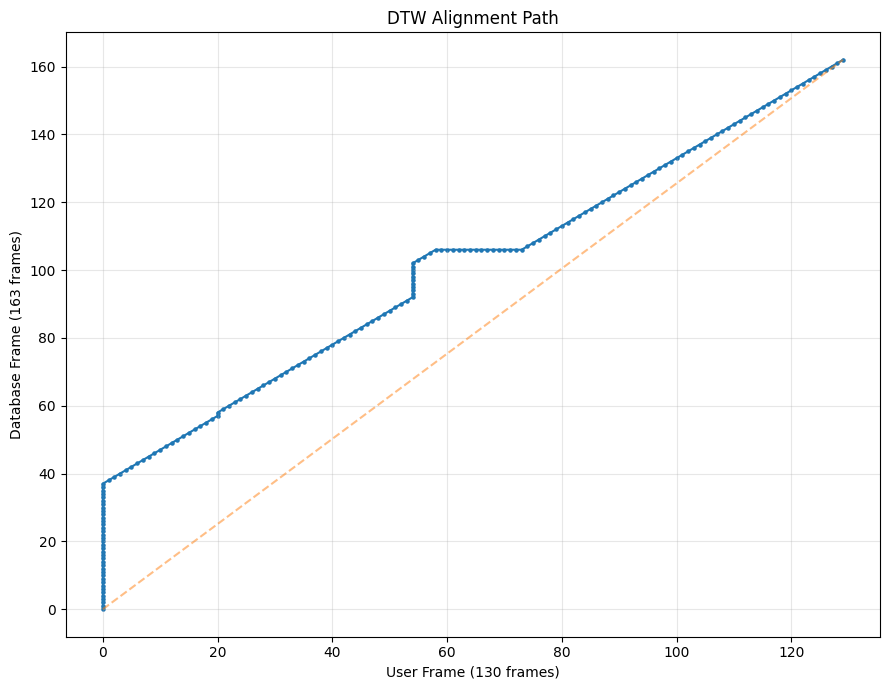

{'distance': 222.06185828418924,
 'path': array([[  0,   0],
        [  0,   1],
        [  0,   2],
        [  0,   3],
        [  0,   4],
        [  0,   5],
        [  0,   6],
        [  0,   7],
        [  0,   8],
        [  0,   9],
        [  0,  10],
        [  0,  11],
        [  0,  12],
        [  0,  13],
        [  0,  14],
        [  0,  15],
        [  0,  16],
        [  0,  17],
        [  0,  18],
        [  0,  19],
        [  0,  20],
        [  0,  21],
        [  0,  22],
        [  0,  23],
        [  0,  24],
        [  0,  25],
        [  0,  26],
        [  0,  27],
        [  0,  28],
        [  0,  29],
        [  0,  30],
        [  0,  31],
        [  0,  32],
        [  0,  33],
        [  0,  34],
        [  0,  35],
        [  0,  36],
        [  0,  37],
        [  1,  38],
        [  2,  39],
        [  3,  40],
        [  4,  41],
        [  5,  42],
        [  6,  43],
        [  7,  44],
        [  8,  45],
        [  9,  46],
        [ 10,  47],

In [ ]:
# plt 繪圖結果
show_last_dtw()